# K-mer analysis (5-mer)

This notebook counts **5-mers** from multiple FASTA files (e.g. `*_pos.fa`) and prepares a **RBP_Cell × 5-mer** matrix for downstream visualization.


In [ ]:
# -----------------------------
# 0) Imports and global settings
# -----------------------------
from __future__ import annotations

import os
import itertools
from collections import Counter
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import pandas as pd

## 1) Configure paths

Edit the paths below to match your environment.


In [ ]:
# Input directory that contains many files like: <RBP_Cell>_pos.fa
INPUT_DIR = Path("../../dataset/")
# File containing RBP_Cell -> number of positive samples (2 columns, tab-separated, no header)
POS_NUM_TSV = Path("./RBP_cell_pos_num_sorted.tsv")


def count_pos_samples(fa_path: Path) -> int:
    """
    Count positive samples in a *_pos.fa file by counting lines starting with '>'.

    Each sample is expected to look like:
        >header
        SEQUENCE
        score1,score2,...

    So counting header lines is sufficient and robust.
    """
    n = 0
    with fa_path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.startswith(">"):
                n += 1
    return n


def main():
    results = []

    # Find all *_pos.fa files
    for fa_path in sorted(INPUT_DIR.glob("*_pos.fa")):
        # Example: PABPC4_K562_pos.fa -> PABPC4_K562
        rbp_cell = fa_path.name[:-len("_pos.fa")]
        pos_num = count_pos_samples(fa_path)
        results.append((rbp_cell, pos_num))

    # Sort by RBP_Cell name
    results.sort(key=lambda x: x[0])

    # Write TSV
    POS_NUM_TSV.parent.mkdir(parents=True, exist_ok=True)
    with POS_NUM_TSV.open("w", encoding="utf-8") as out:
        for rbp_cell, pos_num in results:
            out.write(f"{rbp_cell}\t{pos_num}\n")

    print(f"Done. Wrote {len(results)} entries to: {POS_NUM_TSV}")


if __name__ == "__main__":
    main()

Done. Wrote 261 entries to: RBP_cell_pos_num_sorted.tsv


In [ ]:

OUT_MATRIX_RATIO = Path("./all_5mer_occur_matrix_ratio.txt")

# k-mer length
K = 5

# Alphabet used to enumerate all kmers (order matters only for column order)
BASES = ["A", "C", "G", "T"]

# Quick sanity check
assert INPUT_DIR.exists(), f"INPUT_DIR not found: {INPUT_DIR.resolve()}"


## 2) Helper functions (FASTA parsing + counting)

These functions are intentionally small and documented so others can reuse them.


In [ ]:
def iter_fasta_sequences(path: Path) -> Iterable[str]:
    """Yield sequences from a FASTA file.

    Parameters
    ----------
    path
        Path to a FASTA file. Header lines start with '>' and are ignored.

    Yields
    ------
    str
        Concatenated sequence string per record (uppercase, with whitespace removed).

    Notes
    -----
    - If a record spans multiple lines, we concatenate them.
    - We do not validate characters here (validation happens in counting functions).
    """
    seq_chunks: List[str] = []
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                # flush previous record (if any)
                if seq_chunks:
                    yield "".join(seq_chunks).upper()
                    seq_chunks = []
            else:
                seq_chunks.append(line)
        if seq_chunks:
            yield "".join(seq_chunks).upper()


def all_kmers(k: int, alphabet: List[str]) -> List[str]:
    """Generate all possible k-mers from an alphabet."""
    return ["".join(p) for p in itertools.product(alphabet, repeat=k)]


def count_kmers_in_sequence(seq: str, k: int) -> Counter:
    """Count all k-mers in a single sequence (overlapping).

    Parameters
    ----------
    seq
        DNA/RNA sequence (expected A/C/G/T). Any k-mer containing non-ACGT is skipped.
    k
        k-mer length.

    Returns
    -------
    Counter
        Mapping {kmer: count}.
    """
    seq = seq.upper()
    c = Counter()
    for i in range(len(seq) - k + 1):
        kmer = seq[i : i + k]
        # Skip kmers with ambiguous bases (N, etc.)
        if set(kmer) <= {"A", "C", "G", "T"}:
            c[kmer] += 1
    return c


def count_kmers_in_fasta(path: Path, k: int) -> Counter:
    """Count k-mers across all records in a FASTA file."""
    total = Counter()
    for seq in iter_fasta_sequences(path):
        total.update(count_kmers_in_sequence(seq, k=k))
    return total


def count_acgt_in_fasta(path: Path) -> Dict[str, int]:
    """Count A/C/G/T letter totals across all sequences in a FASTA file."""
    counts = Counter()
    for seq in iter_fasta_sequences(path):
        counts.update([b for b in seq if b in {"A", "C", "G", "T"}])
    return {b: int(counts.get(b, 0)) for b in ["A", "C", "G", "T"]}

## 3) Enumerate input files (`*_pos.fa`)

We derive `RBP_Cell` from the filename by removing the suffix `_pos.fa`.


In [ ]:
# Collect all *_pos.fa files
fa_files = sorted(INPUT_DIR.glob("*_pos.fa"))
print("Found", len(fa_files), "files")

Found 261 files


## 4) Count 5-mers for each file

This produces a *long* table: one row per (`RBP_Cell`, `5mer`).


In [ ]:
# Precompute all possible kmers to keep a consistent column set later
kmers = all_kmers(K, BASES)

rows = []
for fp in fa_files:
    rbp_cell = fp.name.replace("_pos.fa", "")
    kmer_counts = count_kmers_in_fasta(fp, k=K)

    # Emit rows for all kmers (including zeros) to make downstream pivot predictable
    for kmer in kmers:
        rows.append((rbp_cell, kmer, int(kmer_counts.get(kmer, 0))))

counts_df = pd.DataFrame(rows, columns=["RBP_Cell", f"{K}mer", "Count"])
counts_df.head()

,RBP_Cell,5mer,Count
0,AARS_K562,AAAAA,1049
1,AARS_K562,AAAAC,560
2,AARS_K562,AAAAG,889
3,AARS_K562,AAAAT,540
4,AARS_K562,AAACA,554


## 5) Build the wide matrix (RBP_Cell × 5-mer)

We pivot the long table into a matrix-like DataFrame.


In [ ]:
matrix_counts = (
    counts_df
    .pivot(index="RBP_Cell", columns=f"{K}mer", values="Count")
    .fillna(0)
    .astype(int)
)

print("matrix_counts shape:", matrix_counts.shape)
matrix_counts.iloc[:5, :8]

matrix_counts shape: (261, 1024)


5mer,AAAAA,AAAAC,AAAAG,AAAAT,AAACA,AAACC,AAACG,AAACT
RBP_Cell,,,,,,,,
AARS_K562,1049,560,889,540,554,411,157,415
AATF_K562,235,189,295,204,212,289,88,235
ABCF1_K562,476,273,478,283,308,285,120,277
AGGF1_HepG2,1508,567,1420,596,592,463,220,423
AGGF1_K562,1338,632,1347,685,728,456,209,569


## 6) Normalize by number of positive samples per RBP_Cell

If you have a table like `RBP_cell_pos_num_sorted.tsv`, we can compute:

`matrix_ratio[RBP_Cell, kmer] = matrix_counts[RBP_Cell, kmer] / Pos_Num[RBP_Cell]`

This is useful when different `RBP_Cell` have very different numbers of sequences.


In [ ]:
# Load positive sample counts (if available)
pos_num = pd.read_csv(POS_NUM_TSV, sep="\t", header=None, names=["RBP_Cell", "Pos_Num"])
pos_num = pos_num.set_index("RBP_Cell")["Pos_Num"].astype(float)
pos_num.head()

RBP_Cell
AARS_K562      5000.0
AATF_K562      5000.0
ABCF1_K562     5000.0
AGGF1_HepG2    5000.0
AGGF1_K562     5000.0
Name: Pos_Num, dtype: float64

In [ ]:
# Align indices and divide row-wise
common = matrix_counts.index.intersection(pos_num.index)
matrix_ratio = matrix_counts.loc[common].div(pos_num.loc[common], axis=0)

matrix_ratio.iloc[:5, :8]
matrix_ratio.head()

5mer,AAAAA,AAAAC,AAAAG,AAAAT,AAACA,AAACC,AAACG,AAACT,AAAGA,AAAGC,...,TTTCG,TTTCT,TTTGA,TTTGC,TTTGG,TTTGT,TTTTA,TTTTC,TTTTG,TTTTT
RBP_Cell,,,,,,,,,,,,,,,,,,,,,
AARS_K562,0.2098,0.1120,0.1778,0.1080,0.1108,0.0822,0.0314,0.0830,0.2150,0.1158,...,0.0276,0.1118,0.1090,0.0858,0.1270,0.0950,0.0700,0.1028,0.1082,0.1658
AATF_K562,0.0470,0.0378,0.0590,0.0408,0.0424,0.0578,0.0176,0.0470,0.0686,0.0680,...,0.0314,0.1014,0.0796,0.0754,0.1182,0.0806,0.0464,0.0916,0.0922,0.1366
ABCF1_K562,0.0952,0.0546,0.0956,0.0566,0.0616,0.0570,0.0240,0.0554,0.1232,0.0916,...,0.0240,0.0610,0.0816,0.0650,0.0806,0.0582,0.0358,0.0490,0.0548,0.0738
AGGF1_HepG2,0.3016,0.1134,0.2840,0.1192,0.1184,0.0926,0.0440,0.0846,0.3048,0.1532,...,0.0196,0.0996,0.1038,0.0754,0.1246,0.0736,0.0620,0.0794,0.0950,0.1402
AGGF1_K562,0.2676,0.1264,0.2694,0.1370,0.1456,0.0912,0.0418,0.1138,0.3258,0.1430,...,0.0246,0.1042,0.1320,0.0824,0.1184,0.0852,0.0686,0.0852,0.1146,0.1216


In [ ]:
if matrix_ratio is not None:
    matrix_ratio.to_csv(OUT_MATRIX_RATIO, sep="\t")
    print("Saved:", OUT_MATRIX_RATIO.resolve())

Saved: /fs1/private/user/wangyubo/code/BRIDGE/reproducibility/Fig5/all_5mer_occur_matrix_ratio.txt


## 7) Quick base composition (A/C/G/T) per file

Sometimes it’s helpful to check if a dataset is strongly biased in base composition.


In [ ]:
base_rows = []
for fp in fa_files:
    rbp_cell = fp.name.replace("_pos.fa", "")
    acgt = count_acgt_in_fasta(fp)
    base_rows.append({"RBP_Cell": rbp_cell, **acgt})

base_counts_df = pd.DataFrame(base_rows).sort_values("RBP_Cell")
base_counts_df.head()

,RBP_Cell,A,C,G,T
0,AARS_K562,123805,124817,153661,102716
1,AATF_K562,92226,147342,166907,98525
2,ABCF1_K562,105062,153730,156406,89800
3,AGGF1_HepG2,131648,121766,152748,98838
4,AGGF1_K562,134021,120574,148468,101935


## 8) Heatmap in R
```{note}
You have two options in Jupyter:

1. **Use an R kernel** (IRkernel): run R code cells normally.
2. **Use Python kernel + rpy2 magic**: install `rpy2` and then use `%%R` at the top of the cell.

Below is a ready-to-run R script.
```

In [12]:
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(ggplot2)
  library(ggplotify)
})

In [13]:
# =========================
# User parameters
# =========================

INPUT_FILE <- "all_5mer_occur_matrix_ratio.txt"

# Output files
OUT_HEATMAP_PNG <- "kmer_heatmap.png"
OUT_NT_PNG      <- "nucleotide.png"

# Heatmap canvas size (pixels)
HEATMAP_PX <- 600
NT_WIDTH_IN <- 6
NT_HEIGHT_IN <- 0.8
NT_DPI <- 250

# Scaling / transformation
# NOTE: In base R, scale(mat) works COLUMN-wise by default.
DO_SCALE <- TRUE
SCALE_CENTER <- TRUE
SCALE_SCALE  <- TRUE

# Truncation (winsorization) quantiles
LOWER_Q <- 0.01
UPPER_Q <- 0.99

# ComplexHeatmap options
SHOW_ROW_NAMES <- FALSE
SHOW_COL_NAMES <- FALSE
SHOW_COL_DEND  <- FALSE
SET_CLUSTER_COLUMNS <- FALSE
CLUSTER_COLUMNS_VALUE <- TRUE  # only used if SET_CLUSTER_COLUMNS=TRUE

# Color mapping for main heatmap
MAIN_COLORS <- c("#aba1bf", "white", "#e4a350")

# Color mapping for nucleotide strip
NT_COLORS <- c(
  "A" = "#74be9f",
  "C" = "#bee2e0",
  "G" = "#dedbca",
  "T" = "#e8b496"
)


In [14]:
# =========================
# Step 1: Read input matrix
# =========================
# Expected:
# - header = TRUE
# - sep = "\t"
# - row.names = 1  (first column is rownames)
mat <- read.table(INPUT_FILE, header = TRUE, sep = "\t", row.names = 1, check.names = FALSE)

# Convert to numeric matrix
mat <- as.matrix(mat)

# Basic sanity checks
stopifnot(is.matrix(mat))
if (!is.numeric(mat)) {
  stop("Input matrix is not numeric. Please ensure all value columns are numeric.")
}
cat("Matrix dim:", dim(mat)[1], "rows x", dim(mat)[2], "cols\n")


Matrix dim: 261 rows x 1024 cols


In [15]:
# =========================
# Step 2: Z-score scaling
# =========================
# IMPORTANT:
# - Base R's scale() standardizes COLUMNS by default.
#   ranked_mat <- scale(mat, center=TRUE, scale=TRUE) is also COLUMN-wise scaling.
#

ranked_mat <- mat

if (DO_SCALE) {
  ranked_mat <- scale(mat, center = SCALE_CENTER, scale = SCALE_SCALE)
}

In [16]:
# =========================
# Step 3: Quantile truncation (winsorization)
# =========================
lower <- as.numeric(quantile(ranked_mat, LOWER_Q, na.rm = TRUE))
upper <- as.numeric(quantile(ranked_mat, UPPER_Q, na.rm = TRUE))

ranked_mat <- pmax(pmin(ranked_mat, upper), lower)

# =========================
# Step 4: Color mapping
# =========================
col_fun <- colorRamp2(
  c(min(ranked_mat, na.rm = TRUE),
    mean(ranked_mat, na.rm = TRUE),
    max(ranked_mat, na.rm = TRUE)),
  MAIN_COLORS
)


In [17]:
# =========================
# Step 5: Build ComplexHeatmap object
# =========================
# - If you do NOT pass cluster_columns, ComplexHeatmap uses its default.
#
# If you want to explicitly control clustering later, set:
#   SET_CLUSTER_COLUMNS <- TRUE
#   CLUSTER_COLUMNS_VALUE <- FALSE/TRUE

if (SET_CLUSTER_COLUMNS) {
  ht <- Heatmap(
    ranked_mat,
    show_row_names = SHOW_ROW_NAMES,
    show_column_names = SHOW_COL_NAMES,
    show_column_dend = SHOW_COL_DEND,
    cluster_columns = CLUSTER_COLUMNS_VALUE,
    col = col_fun
  )
} else {
  ht <- Heatmap(
    ranked_mat,
    show_row_names = SHOW_ROW_NAMES,
    show_column_names = SHOW_COL_NAMES,
    show_column_dend = SHOW_COL_DEND,
    col = col_fun
  )
}


In [18]:
# =========================
# Step 6: Save heatmap to PNG
# =========================
png(OUT_HEATMAP_PNG, width = HEATMAP_PX, height = HEATMAP_PX)
draw(ht)
dev.off()
cat("Saved main heatmap:", OUT_HEATMAP_PNG, "\n")


pdf 
  2

Saved main heatmap: kmer_heatmap.png 


In [19]:
# =========================
# Step 7: Extract clustered column order
# =========================

# Note: column_order(ht) may not always reflect the final drawn order
# if the heatmap has not been drawn yet in the current device.
clustered_columns_A <- colnames(ranked_mat)[column_order(ht)]
cat("Length check A:", length(clustered_columns_A), "\n")

# Choose which one to use for the nucleotide strip.
clustered_columns <- clustered_columns_A


Warning message:
“The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); column_order(ht)`.”


Length check A: 1024 


nt_mat dim: 5 x 1024 


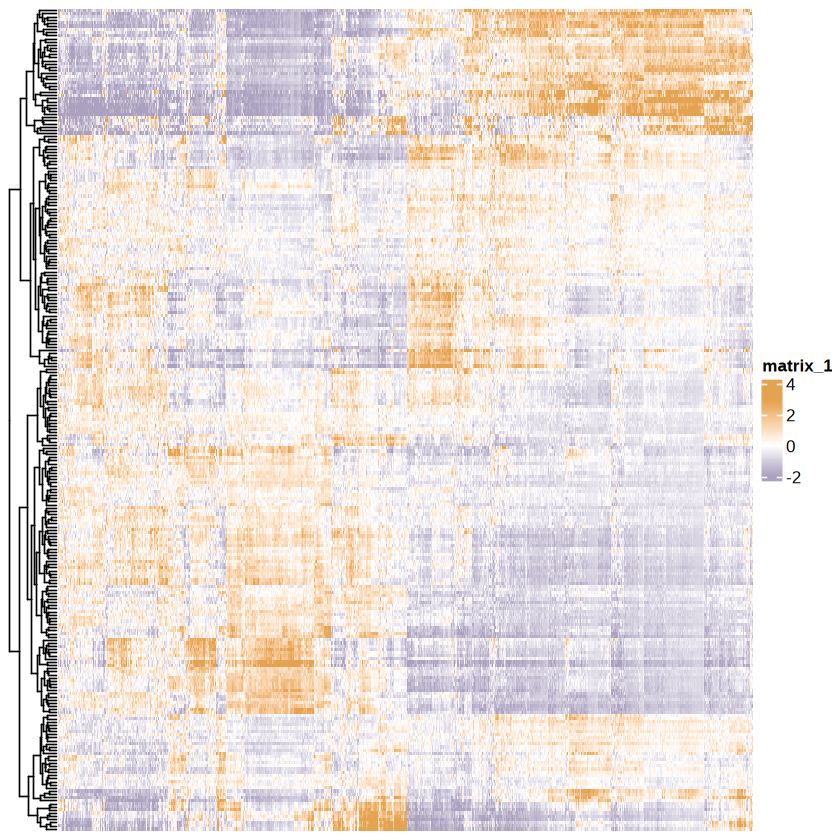

In [20]:
# =========================
# Cell 10: Build nucleotide matrix aligned to FINAL heatmap column order
# =========================

# 1) IMPORTANT: get the FINAL column order from a drawn heatmap object
#    This guarantees the k-mer order matches what you see in the ComplexHeatmap.
ht_drawn <- draw(ht)
col_idx <- column_order(ht_drawn)

# k-mer names in the exact displayed order
clustered_columns <- colnames(ranked_mat)[col_idx]
stopifnot(length(clustered_columns) == ncol(ranked_mat))

# 2) Build a 5 x N matrix: rows are position 1..5 in k-mer, columns are k-mers (ordered)
k <- nchar(clustered_columns[1])
if (any(nchar(clustered_columns) != k)) {
  stop("Inconsistent k-mer lengths detected in clustered_columns.")
}

nt_mat <- matrix(NA_character_, nrow = k, ncol = length(clustered_columns))
for (i in seq_along(clustered_columns)) {
  nt_mat[, i] <- strsplit(clustered_columns[i], "")[[1]]
}

# set dimnames to make downstream melting explicit and stable
rownames(nt_mat) <- as.character(seq_len(k))                      # "1","2","3","4","5"
colnames(nt_mat) <- as.character(seq_len(ncol(nt_mat)))           # "1".."1024"

cat("nt_mat dim:", dim(nt_mat)[1], "x", dim(nt_mat)[2], "\n")


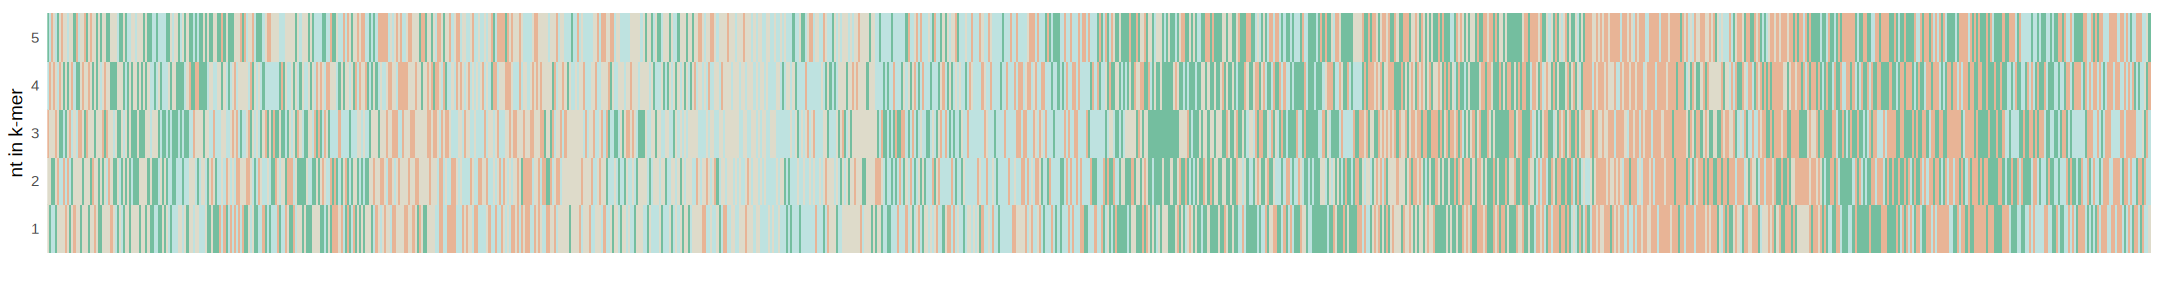

In [21]:
# =========================
# Cell 11: Plot nucleotide strip (no reordering)
# =========================

# Convert nt_mat to long format WITHOUT factor reordering issues
# We'll use numeric column indices for x (1..1024), so ggplot never sorts as strings.
df_nt <- as.data.frame(as.table(nt_mat), stringsAsFactors = FALSE)
colnames(df_nt) <- c("Pos", "Idx", "Nucleotide")

df_nt$Pos <- as.integer(df_nt$Pos)   # 1..5
df_nt$Idx <- as.integer(df_nt$Idx)   # 1..1024

# If you want position 1 at the TOP (common in motif logos), flip y:
# Uncomment the next line:
# df_nt$Pos <- factor(df_nt$Pos, levels = 5:1)

# Otherwise keep 1 at bottom (default ggplot):
df_nt$Pos <- factor(df_nt$Pos, levels = 1:5)

color_mapping <- c(
  "A" = "#74be9f",
  "C" = "#bee2e0",
  "G" = "#dedbca",
  "T" = "#e8b496"
)

acgt_heatmap <- ggplot(df_nt, aes(x = Idx, y = Pos, fill = Nucleotide)) +
  geom_tile(width = 1, height = 1) +
  scale_fill_manual(values = color_mapping, drop = FALSE) +
  scale_x_continuous(expand = c(0, 0), breaks = NULL) +
  scale_y_discrete(labels = 1:5) +
  labs(x = "", y = "nt in k-mer") +
  theme_minimal() +
  theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank(),
    panel.grid   = element_blank(),
    legend.position = "none"
  )

ggsave(OUT_NT_PNG, acgt_heatmap, width = 6, height = 0.8, dpi = 250)
options(repr.plot.width = 18, repr.plot.height = 2.4)
acgt_heatmap